# Testing old and new reference genomes
The [old reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_002022765.2/) was published in 2017 from an inbred line at the Haskin Shellfish Research Lab at Rutgers with 87x coverage.

The [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/) was published in 2025 from Muscongus Bay Aquaculture and Yale University with 163x coverage.

I've aligned my sequences to both genomes using the same flags/parameters. Now, I'm curious how my choice in reference genome affects my RNA-seq analysis

## 0. load libraries

In [102]:
library(tidyverse)
library(RColorBrewer) # for color palletes

## 1. load CSVs

### featureCounts summary

In [40]:
newRef.counts <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/processing/qc_outputs/featureCounts_summary_newRef.csv') %>%
mutate(Sample = str_remove(Sample, "\\.bam$")) %>% # remove ".bam" at the end
mutate(Sample = str_remove(Sample, "^counts_")) %>%   # remove "counts_" at start
mutate(ref_genome = 'new') %>%
slice(1:120) # keep only the first 120 rows: seems like i accidentally duplicated rows when generating this csv
head(newRef.counts)

,Sample,Assigned,Unassigned_Unmapped,Unassigned_Read_Type,Unassigned_Singleton,Unassigned_MappingQuality,Unassigned_Chimera,Unassigned_FragmentLength,Unassigned_Duplicate,Unassigned_MultiMapping,Unassigned_Secondary,Unassigned_NonSplit,Unassigned_NoFeatures,Unassigned_Overlapping_Length,Unassigned_Ambiguity,ref_genome
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,B1_B1_O01,42575470,20404042,0,0,0,0,0,0,8764110,0,0,1325055,0,3709262,new
2,B1_Nu_O03,60154873,28795872,0,0,0,0,0,0,13904187,0,0,1844923,0,4995194,new
3,B1_W5_O50,40669850,19026018,0,0,0,0,0,0,10003575,0,0,1164887,0,3535442,new
4,B2_B5_O51,44831889,22358261,0,0,0,0,0,0,10875146,0,0,1308727,0,3798714,new
5,B2_C4_O40,44115239,22923083,0,0,0,0,0,0,15346996,0,0,1391699,0,3789417,new
6,B2_Nu_O12,60625126,30867204,0,0,0,0,0,0,12780841,0,0,1492057,0,4820846,new


In [43]:
oldRef.counts <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/processing/qc_outputs/featureCounts_summary.csv') %>%
mutate(ref_genome = 'old') %>%
mutate(Sample = str_remove(Sample, "^counts_"))   # remove "counts_" at start

head(oldRef.counts)

,Sample,Assigned,Unassigned_Unmapped,Unassigned_Read_Type,Unassigned_Singleton,Unassigned_MappingQuality,Unassigned_Chimera,Unassigned_FragmentLength,Unassigned_Duplicate,Unassigned_MultiMapping,Unassigned_Secondary,Unassigned_NonSplit,Unassigned_NoFeatures,Unassigned_Overlapping_Length,Unassigned_Ambiguity,ref_genome
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,B1_B1_O01,43560302,13364315,0,0,0,0,0,0,17626841,0,0,7292854,0,1315530,old
2,B1_Nu_O03,61112992,18535006,0,0,0,0,0,0,27272204,0,0,10638161,0,1889859,old
3,B1_W5_O50,41697027,12006768,0,0,0,0,0,0,19337191,0,0,7014364,0,1263414,old
4,B2_B5_O51,46515407,13001667,0,0,0,0,0,0,21897610,0,0,8567980,0,1410398,old
5,B2_C4_O40,45537802,13858521,0,0,0,0,0,0,25570278,0,0,9058567,0,1460110,old
6,B2_Nu_O12,62786888,17374948,0,0,0,0,0,0,22900081,0,0,12562764,0,1714702,old


### featureCounts matrix

In [142]:
new.matrix <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')
dim(new.matrix)
head(new.matrix)

old.matrix <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/featureCounts/featureCounts_matrix.csv')
dim(old.matrix)
head(old.matrix)

[1] 33903   122

,Gene_ID,Length,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,LOC144621260,36658,2626,2649,2072,2158,2074,3974,1207,1181,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
2,LOC144621269,25160,55,580,1632,2484,1011,20011,2110,886,⋯,6,620,44,101,9226,16,2,4034,383,9803
3,LOC111120925,3392,70,4,23,469,11,18,15,7,⋯,3,452,82,28,5,1,0,11,11,9
4,Trnae-cuc,72,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,Trnae-cuc-2,72,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,Trnae-cuc-3,72,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 38838   122

,Gene_ID,Length,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,LOC111116054,1017,2,1,6,10,9,16,0,10,⋯,9,2,8,5,2,19,1,2,1,0
2,LOC111126949,4364,885,652,477,654,586,523,392,357,⋯,407,740,707,406,418,424,492,330,281,599
3,LOC111110729,23787,64,209,93,63,100,177,76,98,⋯,70,149,121,115,126,108,118,115,127,213
4,LOC111112434,9649,11,7,2,0,2,2,12,15,⋯,11,6,4,0,2,16,22,0,8,0
5,LOC111120752,6621,360,586,336,426,351,417,236,278,⋯,359,345,438,278,287,416,621,251,333,430
6,LOC111128944,1773,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,1,0,0


### pipeline counts
generated from [pipeline_counts.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/pipeline_counts.ipynb)

In [125]:
newPipe.counts <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/processing/qc_outputs/newRef_pipeline_counts.csv') %>%
mutate(ref_genome = 'new')
head(newPipe.counts)

oldPipe.counts <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/processing/qc_outputs/pipeline_counts.csv') %>%
mutate(ref_genome = 'old')
head(oldPipe.counts)

combo.pipeCounts <- rbind(newPipe.counts, oldPipe.counts)
head(combo.pipeCounts)

,Sample,raw.reads,paired.reads,total.success.paired,overall.align.rate.percent,aligned.paired.reads,total.assigned.reads,paired.assigned.reads,align.assign.percent,ref_genome
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,71065074,35505181,71010362,71.27,25304542,42575470,21287735,84.13,new
2,B1_Nu_O03,100556142,50245777,100491554,71.34,35845337,60154873,30077436,83.91,new
3,B1_W5_O50,67779272,33866604,67733208,71.91,24353475,40669850,20334925,83.50,new
4,B2_B5_O51,76008956,37979887,75959774,70.57,26802406,44831889,22415944,83.63,new
5,B2_C4_O40,77162786,38556483,77112966,70.27,27093641,44115239,22057620,81.41,new
6,B2_Nu_O12,102409148,51170017,102340034,69.84,35737140,60625126,30312563,84.82,new


,Sample,raw.reads,paired.reads,total.success.paired,overall.align.rate.percent,aligned.paired.reads,total.assigned.reads,paired.assigned.reads,align.assign.percent,ref_genome
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,71065074,35505181,71010362,81.18,28823106,43560302,21780151,75.56,old
2,B1_Nu_O03,100556142,50245777,100491554,81.56,40980456,61112992,30556496,74.56,old
3,B1_W5_O50,67779272,33866604,67733208,82.27,27862055,41697027,20848514,74.83,old
4,B2_B5_O51,76008956,37979887,75959774,82.88,31477730,46515407,23257704,73.89,old
5,B2_C4_O40,77162786,38556483,77112966,82.03,31627883,45537802,22768901,71.99,old
6,B2_Nu_O12,102409148,51170017,102340034,83.02,42481348,62786888,31393444,73.90,old


,Sample,raw.reads,paired.reads,total.success.paired,overall.align.rate.percent,aligned.paired.reads,total.assigned.reads,paired.assigned.reads,align.assign.percent,ref_genome
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,71065074,35505181,71010362,71.27,25304542,42575470,21287735,84.13,new
2,B1_Nu_O03,100556142,50245777,100491554,71.34,35845337,60154873,30077436,83.91,new
3,B1_W5_O50,67779272,33866604,67733208,71.91,24353475,40669850,20334925,83.50,new
4,B2_B5_O51,76008956,37979887,75959774,70.57,26802406,44831889,22415944,83.63,new
5,B2_C4_O40,77162786,38556483,77112966,70.27,27093641,44115239,22057620,81.41,new
6,B2_Nu_O12,102409148,51170017,102340034,69.84,35737140,60625126,30312563,84.82,new


## 2. Check df contents

### featureCounts matrix

In [149]:
dim(old.matrix)
dim(new.matrix)

[1] 38838   122

[1] 33903   122

about 5000 less genes in the new matrix compared to the old - let's verify that there are less genes in the new reference genome on NCBI
- [old genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_002022765.2/): 39,505 genes
- [new genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/): 35,738 genes

calculate proportion of genes reported in featureCounts compared to actual number of genes:

In [150]:
# old genome
(38838/39505) * 100

# new genome
(33903/35738) * 100

[1] 98.31161

[1] 94.86541

hmmmmm that seems weird? why would there be less genes in the final counts matrix compared to what is reported in the actual reference genome

are the same genes in both references?

In [148]:
list(
  in_both = length(intersect(new.matrix$Gene_ID, old.matrix$Gene_ID)),
  old_only = length(setdiff(old.matrix$Gene_ID, new.matrix$Gene_ID)),
  new_only = length(setdiff(new.matrix$Gene_ID, old.matrix$Gene_ID))
)

$in_both
[1] 24348

$old_only
[1] 14490

$new_only
[1] 9555

woah so like 14.5k genes are dropped/changed in the new reference

### featureCounts summary

Double check all samples are in both dfs

In [44]:
dim(newRef.counts) 
dim(oldRef.counts)

sum(newRef.counts$Sample == oldRef.counts$Sample)

[1] 120  16

[1] 120  16

[1] 120

so we have the same samples - good start lol

combining the dfs so that I can plot and look at the difference in assigned and unassigned reads

In [45]:
combo.counts <- rbind(newRef.counts, oldRef.counts)
head(combo.counts)

,Sample,Assigned,Unassigned_Unmapped,Unassigned_Read_Type,Unassigned_Singleton,Unassigned_MappingQuality,Unassigned_Chimera,Unassigned_FragmentLength,Unassigned_Duplicate,Unassigned_MultiMapping,Unassigned_Secondary,Unassigned_NonSplit,Unassigned_NoFeatures,Unassigned_Overlapping_Length,Unassigned_Ambiguity,ref_genome
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,B1_B1_O01,42575470,20404042,0,0,0,0,0,0,8764110,0,0,1325055,0,3709262,new
2,B1_Nu_O03,60154873,28795872,0,0,0,0,0,0,13904187,0,0,1844923,0,4995194,new
3,B1_W5_O50,40669850,19026018,0,0,0,0,0,0,10003575,0,0,1164887,0,3535442,new
4,B2_B5_O51,44831889,22358261,0,0,0,0,0,0,10875146,0,0,1308727,0,3798714,new
5,B2_C4_O40,44115239,22923083,0,0,0,0,0,0,15346996,0,0,1391699,0,3789417,new
6,B2_Nu_O12,60625126,30867204,0,0,0,0,0,0,12780841,0,0,1492057,0,4820846,new


**column descriptions**:
- Assigned: correctly assigned to a feature
- Unassigned_Unmapped: did not map to the ref genome
- Unassigned_MultiMapping: reads that mapped to multiple locations
- Unassigned_NoFeatures: mapped to the ref genome, but not to any defined genomic feature (so intergenic regions?? or just unknown regions)
- Unassigned_Ambiguity: overlap with multiple features, impossible to assign

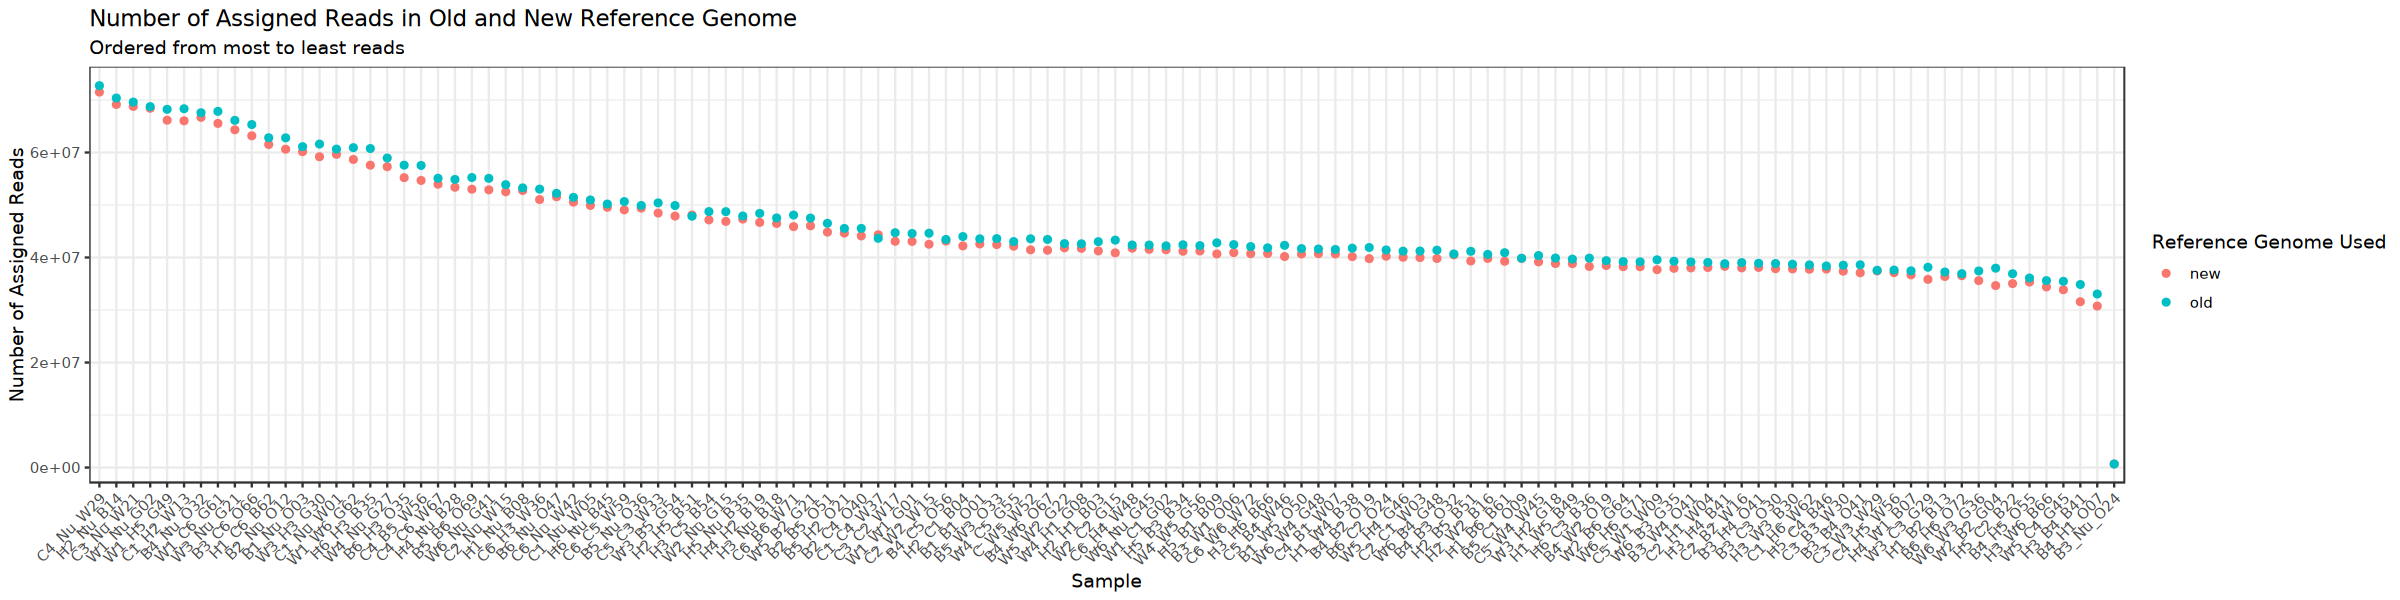

In [58]:
options(repr.plot.width = 20, repr.plot.height = 5)

ggplot(combo.counts, aes(reorder(Sample, -Assigned), y = Assigned, col = ref_genome)) +
geom_point() +
theme_bw() +
labs(title = 'Number of Assigned Reads in Old and New Reference Genome',
    subtitle = 'Ordered from most to least reads',
    x = 'Sample',
    y = 'Number of Assigned Reads',
    col = 'Reference Genome Used') +
# ylim(20000000, 80000000) + # can use this to look more closely at the points by removing outlier
theme(axis.text.x = element_text(angle = 45, hjust = 1))

it appears that the number of assigned reads remains mostly the same for both reference genomes - although aligning with the new reference genome seems to decrease assignment a little, but doesn't appear to be that different or affect one sample more than the other 

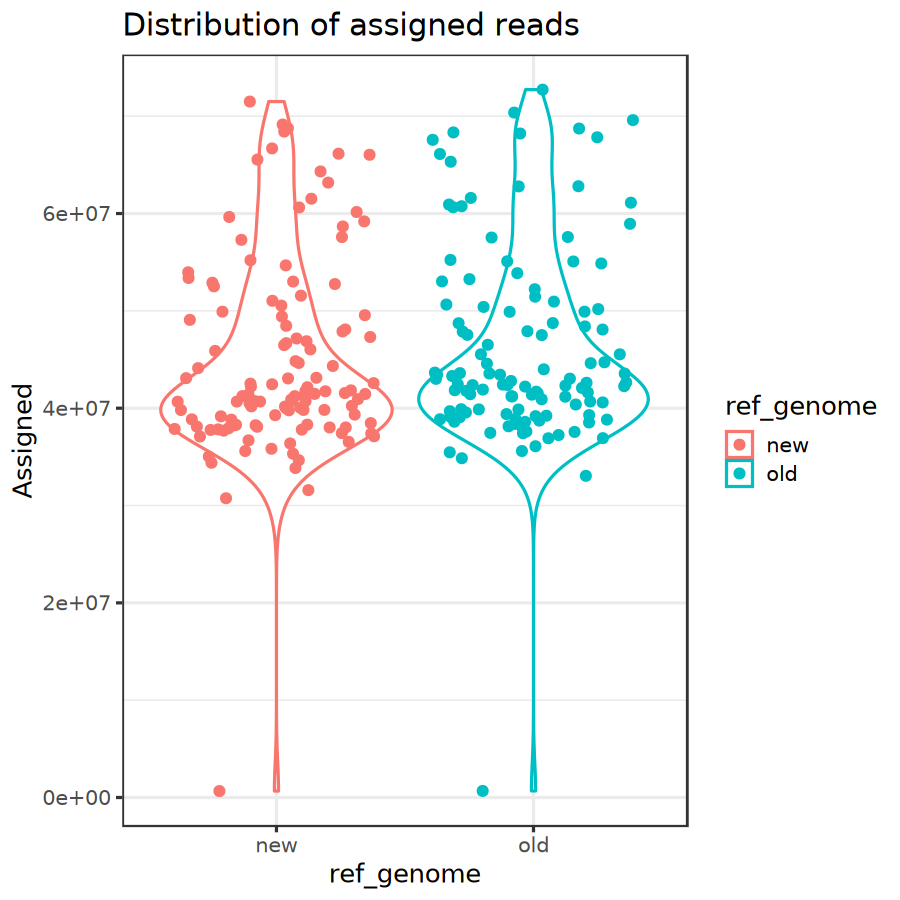

In [64]:
options(repr.plot.width = 7.5, repr.plot.height = 7.5)

ggplot(combo.counts, aes(x=ref_genome, y = Assigned, col = ref_genome)) +
geom_violin() +
geom_jitter() +
labs(title = 'Distribution of assigned reads') + 
theme_bw(base_size = 15) 

appears to be a similar distribution

what about for multi-mapped reads?

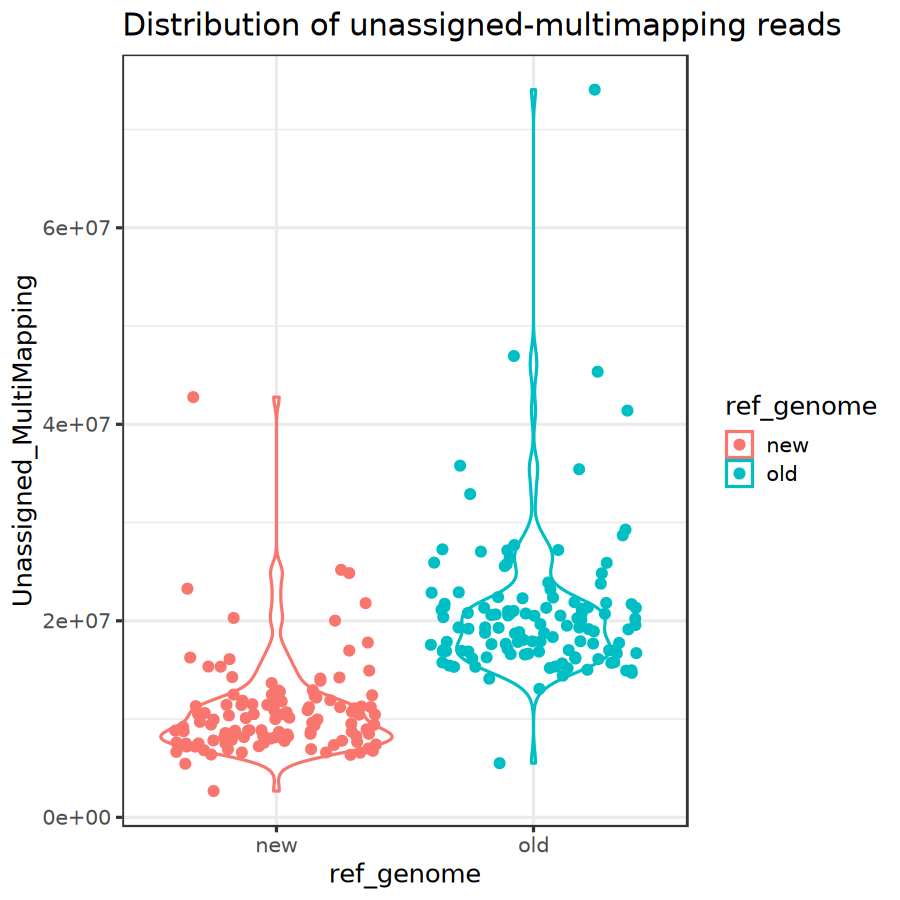

In [63]:
options(repr.plot.width = 7.5, repr.plot.height = 7.5)

ggplot(combo.counts, aes(x=ref_genome, y = Unassigned_MultiMapping	, col = ref_genome)) +
geom_violin() +
geom_jitter() +
labs(title = 'Distribution of unassigned-multimapping reads') + 
theme_bw(base_size = 15) 

i guess this is expected, right, since the percent of the genome duplicated is much less in the new ref genome (1.3%) than the old ref genome (18.7%)

I'm interested in if the proportion of reads in assigned/unassigned categories changed at all

In [66]:
# convert df to long format
combo.long <- combo.counts %>%
  pivot_longer(
    cols = c(Assigned, starts_with("Unassigned_")),
    names_to = "category",
    values_to = "count"
  )

head(combo.long)

Sample,ref_genome,category,count
<chr>,<chr>,<chr>,<int>
B1_B1_O01,new,Assigned,42575470
B1_B1_O01,new,Unassigned_Unmapped,20404042
B1_B1_O01,new,Unassigned_Read_Type,0
B1_B1_O01,new,Unassigned_Singleton,0
B1_B1_O01,new,Unassigned_MappingQuality,0
B1_B1_O01,new,Unassigned_Chimera,0


In [116]:
combo.category <- combo.long %>%
  group_by(category, ref_genome) %>%
filter(count != 0) %>%
  summarise(count = sum(count), .groups = "drop") %>%
mutate(ref_genome = fct_relevel(ref_genome, 'old', 'new'))

combo.category

category,ref_genome,count
<chr>,<fct>,<dbl>
Assigned,new,5387710086
Assigned,old,5548167947
Unassigned_Ambiguity,new,465407708
Unassigned_Ambiguity,old,171393462
Unassigned_MultiMapping,new,1288420866
Unassigned_MultiMapping,old,2507413842
Unassigned_NoFeatures,new,159137947
Unassigned_NoFeatures,old,1115040980
Unassigned_Unmapped,new,2776835709


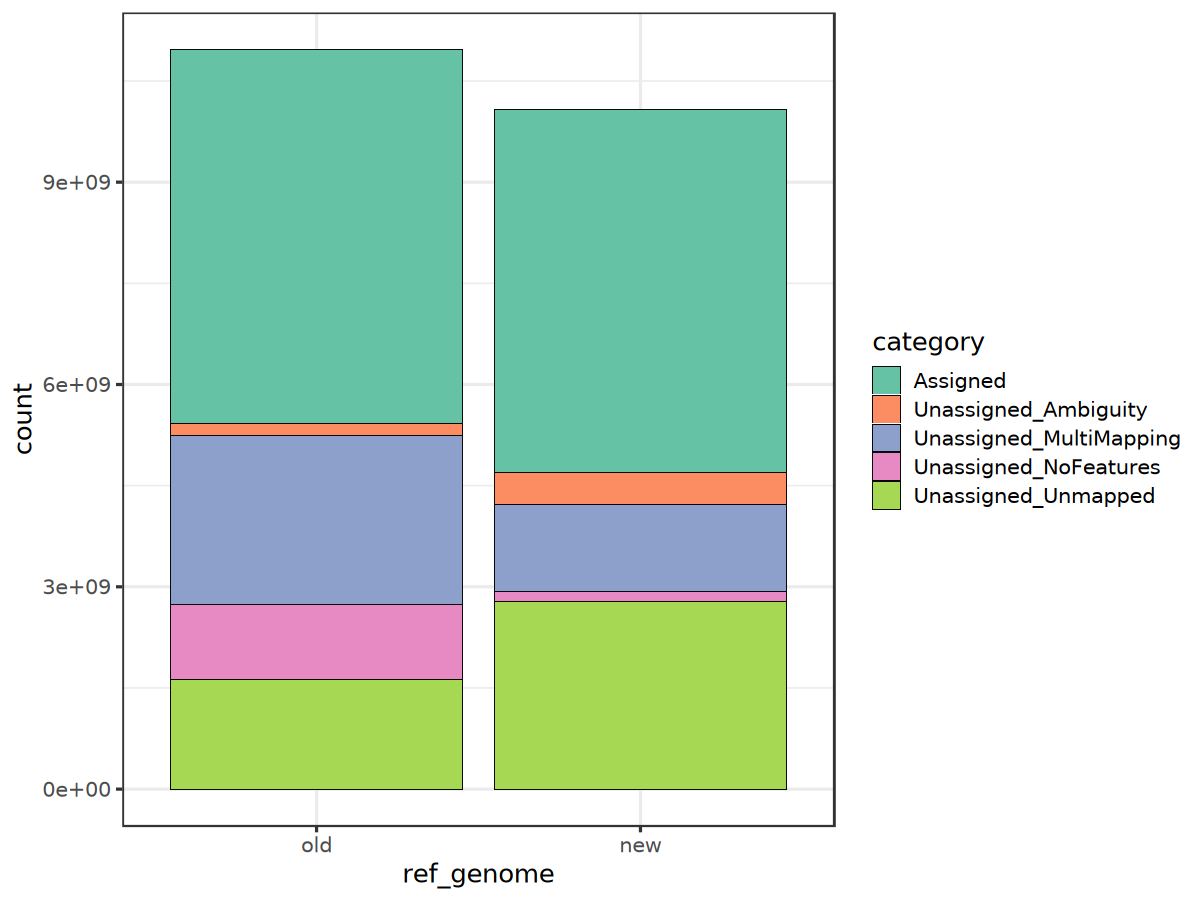

In [118]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

ggplot(combo.category, aes(x = ref_genome, y = count, fill = category)) +
geom_col(position = "stack", col = 'black', linewidth = 0.2) +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 15)

**assignment** = reads that were successfully assigned to a feature (e.g. gene)

what about looking at the proportions?

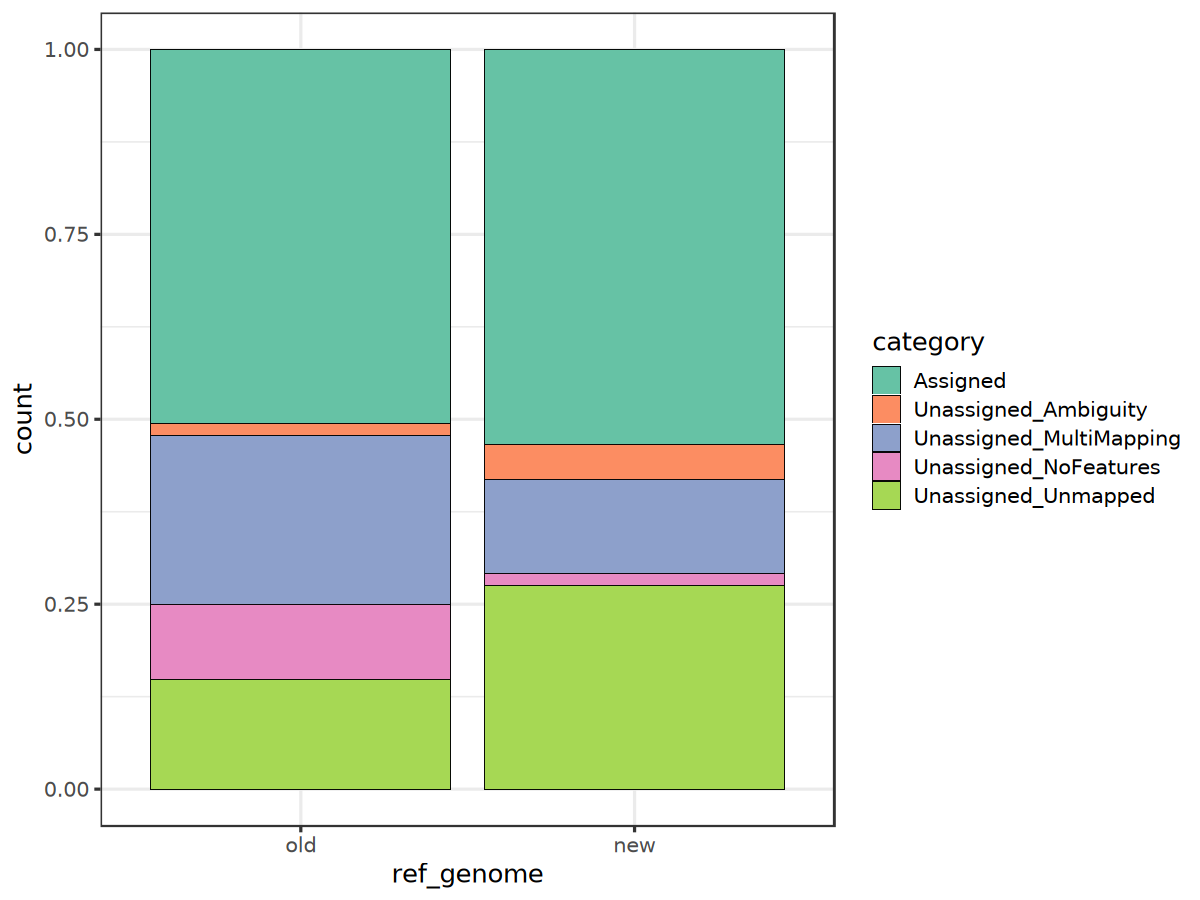

In [120]:
options(repr.plot.width = 10, repr.plot.height = 7.5)

ggplot(combo.category, aes(x = ref_genome, y = count, fill = category)) +
geom_col(position = "fill", col = 'black', linewidth = 0.2) +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 15)

in the **new reference genome**, we see an **increase** in unassigned ambiguity and unmapped reads and a **decrease** in unassigned multimapping and nofeatures

as a reminder, category descriptions:
- Assigned: correctly assigned to a feature
- Unassigned_Unmapped: did not map to the ref genome
- Unassigned_MultiMapping: reads that mapped to multiple locations
- Unassigned_NoFeatures: mapped to the ref genome, but not to any defined genomic feature (so intergenic regions?? or just unknown regions)
- Unassigned_Ambiguity: overlap with multiple features, impossible to assign

so not surprising to see a decrease in multimapping in the new ref genome and no features (bc presumably there's less unknown regions in this genome) - but i guess it is surprising that there's more ambiguity (so multiple features overlapping??) and more unmapped?? 

**potentially important note**: it looks like the *proportion* of assigned reads remains roughly the same, but the category of unassigned reads changes - which makes me feel a little better?

i'm confused though why these aren't the same number ... probably has to do with alignment? i think in general we had lower alignment rates with the new reference genome, so probably good to start there before looking at the featurecounts summaries to make sense of this

let's take a step back and look at alignments

### hisat2 alignments

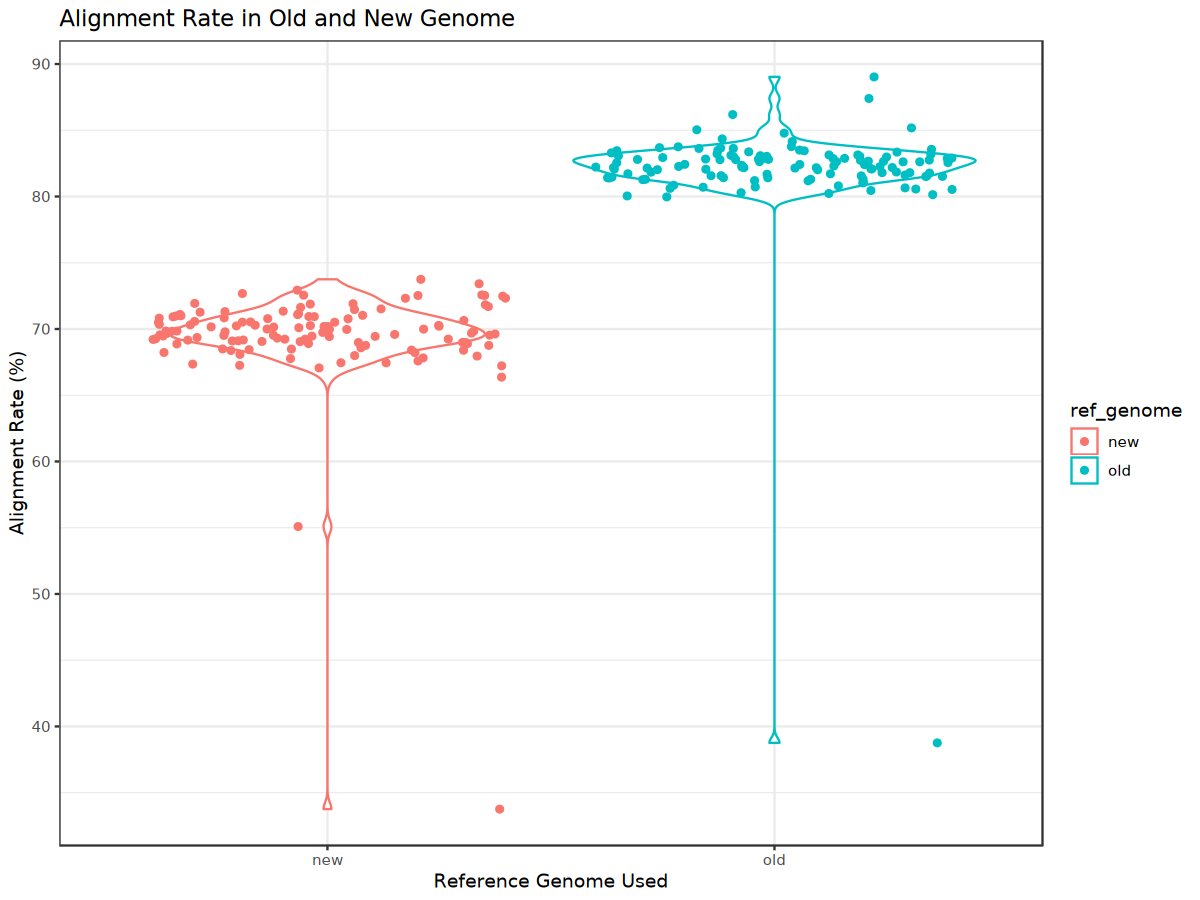

In [135]:
ggplot(combo.pipeCounts, aes(x = ref_genome, y = overall.align.rate.percent, col = ref_genome)) +
geom_violin() +
geom_jitter() +
labs(x = 'Reference Genome Used',
     y = 'Alignment Rate (%)',
     title = 'Alignment Rate in Old and New Genome') +
theme_bw()

**alignment** rate = percent of reads that successfully map *somewhere* in the genome

new reference genome reduces false-positive mappings? (since we observe a reduced alignment rate)

assignment is always lower than alignment bc some genes align to the genome but fall in intergenic regions, overlap multiple genes, and map to non-annotated regions (and featureCounts is stricter than aligners)

it will be interesting to see if gene-level counts become more stable (and less variable)?? I feel like the old data I was working with was pretty noisy ...